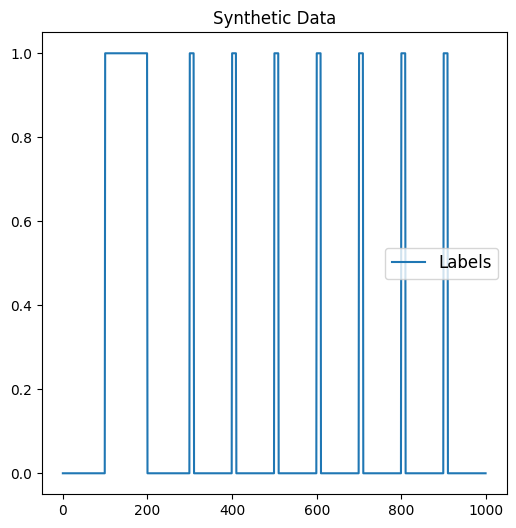

In [13]:
from gragod.metrics.calculator import MetricsCalculator
from gragod.types import Datasets
import torch
import matplotlib.pyplot as plt

def printy_print_dict(dict):
    for key, value in dict.items():
        print(f"    {key}: {value}")


def print_and_plot_metrics(labels, predictions, description, alpha=0.5):
    plt.figure(figsize=(6, 6))
    plt.plot(labels.numpy(), label="Labels")
    plt.plot(predictions.numpy(), label="Predictions")
    plt.legend(fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title(description)
    plt.show()
    metrics_calculator = MetricsCalculator(
        dataset=Datasets.SWAT,
        labels=labels,
        predictions=predictions,
        scores=torch.randn_like(predictions),
    )
    metrics = metrics_calculator.get_all_metrics(alpha=alpha)
    print(f"Metrics for {description}:")
    printy_print_dict(metrics)


synthetic_data = torch.zeros(1000, 1)
synthetic_data[100:200] = 1
for i in range(300, 1000, 100):
    synthetic_data[i : i + 10] = 1

plt.figure(figsize=(6, 6))
plt.plot(synthetic_data.numpy(), label="Labels")
plt.legend(fontsize=12)
plt.title("Synthetic Data")
plt.show()


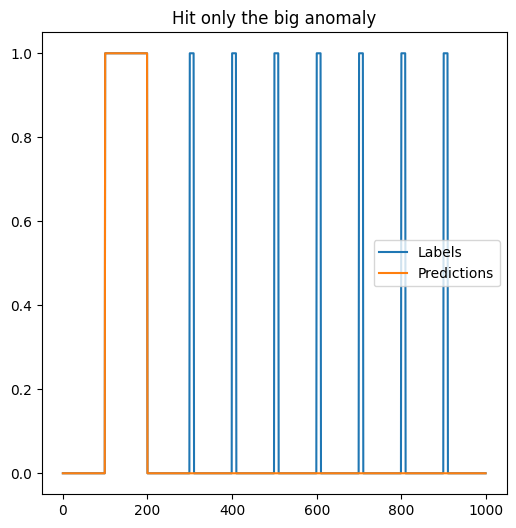

Metrics for Hit only the big anomaly:
    precision_system: 1.0
    recall_system: 0.5882
    f1_system: 0.7407
    range_based_precision_system: 1.0
    range_based_recall_system: 0.125
    range_based_f1_system: 0.2222
    custom_f1_system: 0.2222
    vus_roc_system: 0.5159
    vus_pr_system: 0.1782


In [14]:
only_big_anomaly_prediction = torch.zeros_like(synthetic_data)
only_big_anomaly_prediction[100:200] = 1
print_and_plot_metrics(synthetic_data, only_big_anomaly_prediction, "Hit only the big anomaly")



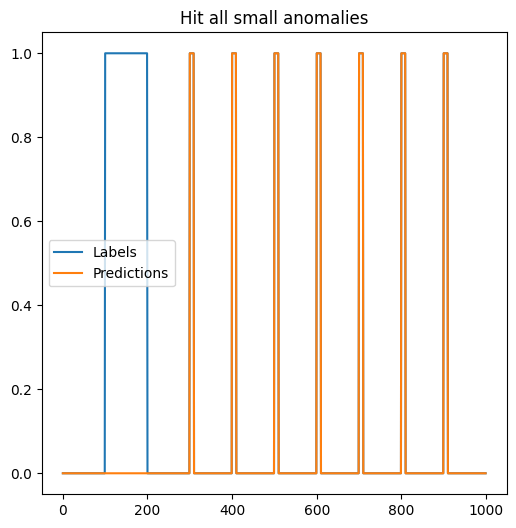

Metrics for Hit all small anomalies:
    precision_system: 1.0
    recall_system: 0.4118
    f1_system: 0.5834
    range_based_precision_system: 1.0
    range_based_recall_system: 0.875
    range_based_f1_system: 0.9333
    custom_f1_system: 0.9333
    vus_roc_system: 0.49
    vus_pr_system: 0.1728


In [16]:
all_small_anomalies_prediction = torch.zeros_like(synthetic_data)
for i in range(300, 1000, 100):
    all_small_anomalies_prediction[i : i + 10] = 1
print_and_plot_metrics(synthetic_data, all_small_anomalies_prediction, "Hit all small anomalies")


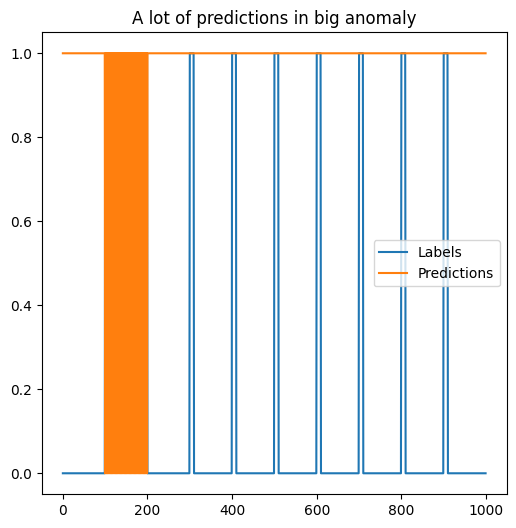

Metrics for A lot of predictions in big anomaly:
    precision_system: 0.1408
    recall_system: 0.8
    f1_system: 0.2395
    range_based_precision_system: 0.9432
    range_based_recall_system: 0.9387
    range_based_f1_system: 0.9409
    custom_f1_system: 0.2449
    vus_roc_system: 0.5053
    vus_pr_system: 0.1793


In [17]:
a_lot_of_predictions = torch.ones_like(synthetic_data)
for i in range(100, 200, 3):
    a_lot_of_predictions[i : i + 1] = 0
print_and_plot_metrics(synthetic_data, a_lot_of_predictions, "A lot of predictions in big anomaly")